In [ ]:
import time
from pickle import PUT
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pytz
from tinkoff.invest import Client, CandleInterval
from tinkoff.invest.utils import now
from datetime import timedelta,datetime,timezone
import numpy as np
import pandas as pd
import datetime
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy import stats
from scipy.optimize import brentq
from pathlib import Path
import time
import pytz
from datetime import timedelta, datetime, timezone
from scipy.optimize import brentq
import scipy.stats as stats


In [ ]:
TOKEN = "" #Введите token T-Api

## Парсер опционов
# В данном куске кода идёт парсинг опционов через T-API, в том числе:
- parsing_datetime - время парсинга
- code - код опциона
- type - тип опционы(Call/Put)
- strike - страйк опциона
- T - время до эспирации в годах
- bid - минимальная цена, за которую готовы купить опцион
- ask - минимальная цена, за которую готовы продать опцион
- BA - цена базового актива
- mid - значение расчитанное по формуле 1/2(bid + ask)
- spread_pct - значение расчитанное по формуле (ask - mid)/mid
- moneyness - значение обозначающие актив находится в деньгах или нет (BA/strike)
- volume - количество заявок

In [ ]:

ISIN = 'RU000A107UL4'

with Client(TOKEN) as client:
    # Получаем инструмент по FIGI
    instrument = client.instruments.find_instrument(query='SBER')
    for i in instrument.instruments:
        if i.api_trade_available_flag == True and i.instrument_type == 'share':
            print(i.api_trade_available_flag)
            print(i.instrument_type)
            print(i.uid)
            print(i.figi)


In [ ]:

UID = "e6123145-9665-43e0-8413-cd61b8aa9b13"

with Client(TOKEN) as client:
    response = client.instruments.options_by(basic_asset_uid="3888b26d-19f3-4a0b-a212-f36b82d6212c")




In [ ]:

rows = []
def q_to_float(q):
    return q.units + q.nano / 1e9
with Client(TOKEN) as client:
    response = client.instruments.options()





In [ ]:
response.instruments[0]

In [ ]:
Options = []
for i in response.instruments:
    if i.basic_asset=="SBER":
        Options.append(i)

In [ ]:

with Client(TOKEN) as client:
    for i in Options:
        time.sleep(0.2)
        parsing_time = datetime.datetime.now()
        base_price_resp = client.market_data.get_last_prices(
        instrument_id=[UID]
    )
        base_price = q_to_float(base_price_resp.last_prices[0].price)
        # стакан
        orderbook = client.market_data.get_order_book(
            instrument_id=i.uid,
            depth=1
        )

        bid = q_to_float(orderbook.bids[0].price) if orderbook.bids else None
        ask = q_to_float(orderbook.asks[0].price) if orderbook.asks else None

        # цена контракта (если lot > 1)
        contract_bid = bid * i.lot if bid else None
        contract_ask = ask * i.lot if ask else None
        option_uid = i.uid
        target_date = datetime.datetime(2026, 2, 25)
        time.sleep(0.2)
        candles = list(client.get_all_candles(
        instrument_id=option_uid,
        from_=target_date,
        to=target_date + timedelta(days=1),
        interval=CandleInterval.CANDLE_INTERVAL_DAY))

        rows.append({
            "parsing_datetime": parsing_time,
            "code": i.ticker,
            "type": i.direction.name.replace("OPTION_DIRECTION_", ""),
            "strike": q_to_float(i.strike_price),
            "T": i.expiration_date.date(),
            "bid": bid,
            "ask": ask,
            "bid": contract_bid,
            "ask": contract_ask,
            "BA": base_price,
            "volume": candles[0].volume if candles else 0

        })
df = pd.DataFrame(rows)

In [ ]:
df.head()

In [ ]:
df.fillna(value=0, inplace=True)
df['mid'] = 0.5*(df['bid'] + df['ask'])
df['spread_pct'] = (df['ask'] - df['bid'])/df['mid']
df['moneyness'] = df['BA']/df['strike']
today = datetime.datetime.now()
df['T'] = pd.to_datetime(df['T'])
df['T'] = (df['T'] - today).dt.days / 365.25

In [ ]:
df['T'] = df['T'].round(3)

In [ ]:
df.head()

In [ ]:
df.to_csv('Options_SBER.csv')


## Парсер Акций СберБанка
# В данном куске кода идёт парсинг акций через T-API, в том числе:
- time - дата, на которую есть цена
- r - лог доходность
- volatility20 - волатильность с окном в 20 дней
- volatility60 - волатильность с окном в 60 дней

In [ ]:
FIGI = "BBG004730N88"

to_date = now()
from_date = to_date - timedelta(days=365*6)
candles_list = []
with Client(TOKEN) as client:
    for candle in client.get_all_candles(
        figi=FIGI,
        from_=from_date,
        to=to_date,
        interval=CandleInterval.CANDLE_INTERVAL_DAY,
    ):
        candles_list.append({
            "time": candle.time,
            "close": candle.close.units + candle.close.nano / 1e9,
        })


df = pd.DataFrame(candles_list)
df.reset_index(drop=True, inplace=True)
df.sort_values(by="time", inplace=True)

print(df.tail())

In [ ]:
df['r'] = np.log(df['close'] / df['close'].shift(1))
df['volatility20'] = df['r'].rolling(window=20).std()
df['volatility60'] = df['r'].rolling(window=60).std()

In [ ]:
df.head()

In [ ]:
df.to_csv('Sber.csv')

## Загрузка данных


In [3]:
Sber = pd.read_csv('SBER.csv')
Options_SBER = pd.read_csv('Options_SBER.csv')

In [6]:
class Black_Sholse:
    def __init__(self,S_0,K,option_type,T,volatility,r = np.log(1+0.1429)):
        self.S_0 = S_0
        self.K = K
        self.option_type = option_type
        self.T = np.abs(T)
        self.r = r
        self.volatility = volatility
    def d1_d2_counter(self):
        d1 = ((np.log(self.S_0/self.K)) + (self.r + 1/2 * self.volatility**2) * self.T)/ (np.sqrt(self.T * (self.volatility**2)))
        d2 = d1 - (np.sqrt(self.volatility**2 * self.T))
        self.d1 = d1
        self.d2 = d2
    def Black_Sholse_call(self):
        self.d1_d2_counter()
        call = self.S_0 * stats.norm.cdf(self.d1) - self.K * stats.norm.cdf(self.d2) * np.exp(-self.r * self.T)
        return call
    def Black_Sholse_put(self):
        self.d1_d2_counter()
        put = self.K * stats.norm.cdf(-self.d2) * np.exp(-self.r * self.T) - self.S_0 * stats.norm.cdf(-self.d1)
        return put
    def Black_Sholse(self):
        self.greeks()
        if self.option_type == 'CALL':
            return self.Black_Sholse_call()
        else:
            return self.Black_Sholse_put()
    def greeks(self):
        self.d1_d2_counter()
        d1 = self.d1
        d2 = self.d2

        pdf = stats.norm.pdf(d1)

        delta_call = stats.norm.cdf(d1)
        delta_put = delta_call - 1

        gamma = pdf / (self.S_0 * self.volatility * np.sqrt(self.T))

        vega = self.S_0 * np.sqrt(self.T) * pdf

        theta_call = (-self.S_0 * pdf * self.volatility / (2 * np.sqrt(self.T))
                      - self.r * self.K * np.exp(-self.r * self.T) * stats.norm.cdf(d2))

        theta_put = (-self.S_0 * pdf * self.volatility / (2 * np.sqrt(self.T))
                     + self.r * self.K * np.exp(-self.r * self.T) * stats.norm.cdf(-d2))

        rho_call = self.K * self.T * np.exp(-self.r * self.T) * stats.norm.cdf(d2)
        rho_put = -self.K * self.T * np.exp(-self.r * self.T) * stats.norm.cdf(-d2)
        if self.option_type == 'CALL':
            self.delta = delta_call
            self.theta = theta_call
            self.vega = vega
            self.rho = rho_call
            self.gamma = gamma
        else:
            self.gamma = gamma
            self.delta = delta_put
            self.theta = theta_put
            self.vega = vega
            self.rho = rho_put



# Подготовка данных

In [11]:
RISK_FREE_RATE = np.log(1 + 0.1429)
USE_VOL_COLUMN = 'volatility20'
N_NEAREST_EXPIRIES = 2
OUTPUT_DIR = Path('AB_outputs')
OUTPUT_DIR.mkdir(exist_ok=True)
OPTIONS_FILE = 'Options_SBER.csv'
UNDERLYING_FILE = 'Sber.csv'
def print_header(title):
    print('\n' + '=' * 80)
    print(title)
    print('=' * 80)


def bs_price(spot, strike, time_to_expiry, rate, sigma, option_type):
    """
    Цена опциона по формуле Black-Scholes.
    """
    if pd.isna(spot) or pd.isna(strike) or pd.isna(time_to_expiry) or pd.isna(sigma):
        return np.nan

    if spot <= 0 or strike <= 0 or time_to_expiry <= 0 or sigma <= 0:
        return np.nan

    d1 = (
        np.log(spot / strike) + (rate + 0.5 * sigma ** 2) * time_to_expiry
    ) / (sigma * np.sqrt(time_to_expiry))

    d2 = d1 - sigma * np.sqrt(time_to_expiry)

    option_type = str(option_type).upper()

    if option_type == 'CALL':
        price = spot * stats.norm.cdf(d1) - strike * np.exp(-rate * time_to_expiry) * stats.norm.cdf(d2)
        return price

    if option_type == 'PUT':
        price = strike * np.exp(-rate * time_to_expiry) * stats.norm.cdf(-d2) - spot * stats.norm.cdf(-d1)
        return price

    return np.nan


def implied_volatility_mid(mid_price, spot, strike, time_to_expiry, rate, option_type,
                           sigma_low=1e-4, sigma_high=5.0):
    """
    Находит implied volatility из mid-цены опциона.
    """
    if pd.isna(mid_price) or pd.isna(spot) or pd.isna(strike) or pd.isna(time_to_expiry):
        return np.nan

    if mid_price <= 0 or spot <= 0 or strike <= 0 or time_to_expiry <= 0:
        return np.nan

    option_type = str(option_type).upper()

    # Проверка на внутреннюю стоимость
    if option_type == 'CALL':
        intrinsic = max(spot - strike * np.exp(-rate * time_to_expiry), 0)
    elif option_type == 'PUT':
        intrinsic = max(strike * np.exp(-rate * time_to_expiry) - spot, 0)
    else:
        return np.nan

    if mid_price < intrinsic:
        return np.nan

    def objective(sigma):
        return bs_price(spot, strike, time_to_expiry, rate, sigma, option_type) - mid_price

    try:
        f_low = objective(sigma_low)
        f_high = objective(sigma_high)

        if np.isnan(f_low) or np.isnan(f_high):
            return np.nan

        if f_low * f_high > 0:
            return np.nan

        iv = brentq(objective, sigma_low, sigma_high, maxiter=500)
        return iv

    except Exception:
        return np.nan


def nearest_expiries(df, n=2):
    """
    Берем n ближайших неистекших экспираций.
    """
    temp = df[df['T'] > 0][['expiration_date', 'T']].dropna().copy()
    temp = temp.sort_values('T').drop_duplicates('expiration_date')
    return temp['expiration_date'].head(n).tolist()
def load_and_prepare_data(options_file, underlying_file):
    options = pd.read_csv(options_file)
    sber = pd.read_csv(underlying_file)
    options = options.loc[:, ~options.columns.str.contains(r'^Unnamed')].copy()
    sber = sber.loc[:, ~sber.columns.str.contains(r'^Unnamed')].copy()
    if 'parsing_datetime' in options.columns:
        options['parsing_datetime'] = pd.to_datetime(options['parsing_datetime'], errors='coerce')
    if 'time' in sber.columns:
        sber['time'] = pd.to_datetime(sber['time'], errors='coerce')
        sber = sber.sort_values('time').reset_index(drop=True)
    numeric_cols = ['strike', 'T', 'bid', 'ask', 'BA', 'volume', 'mid', 'spread_pct', 'moneyness']
    for col in numeric_cols:
        if col in options.columns:
            options[col] = pd.to_numeric(options[col], errors='coerce')
    if 'mid' not in options.columns:
        options['mid'] = 0.5 * (options['bid'] + options['ask'])
    if 'spread_pct' not in options.columns:
        options['spread_pct'] = np.where(
            options['mid'] > 0,
            (options['ask'] - options['bid']) / options['mid'],
            np.nan
        )
    if 'moneyness' not in options.columns:
        options['moneyness'] = options['BA'] / options['strike']
    options['expiration_date'] = (
        options['parsing_datetime'] + pd.to_timedelta(options['T'] * 365.25, unit='D')
    ).dt.normalize()
    options['is_quoted'] = (options['bid'] > 0) & (options['ask'] > 0)
    options['abs_mny_distance'] = np.abs(options['moneyness'] - 1)
    sber['annualized_vol'] = sber[USE_VOL_COLUMN] * np.sqrt(252)
    latest_spot_row = sber.dropna(subset=['time', 'close']).sort_values('time').iloc[-1]
    latest_spot = float(latest_spot_row['close'])
    latest_hist_vol = float(latest_spot_row['annualized_vol'])
    return options, sber, latest_spot, latest_hist_vol
options, sber, latest_spot, latest_hist_vol = load_and_prepare_data(
    OPTIONS_FILE,
    UNDERLYING_FILE
)


# Прверка БШМ

> **_volatility** - фиксированная годовая волатильность в модели Блэка-Шоулза, примем ее как историческую волатильность актива

In [22]:
_volatility = Sber['r'].std() * np.sqrt(252)
_volatility

0.3710643678227356

In [12]:
_models = options.apply(
    lambda x:
    Black_Sholse(
        S_0=x['BA'], K=x['strike'], option_type=x['type'], T=x['T'], volatility=_volatility
    ), axis=1
)

In [13]:
_model_prices = _models.apply(
    lambda m: m.Black_Sholse_call() if m.option_type == "CALL" else m.Black_Sholse_put()
)
model_prices_df = pd.DataFrame({
    'code': Options_SBER['code'],
    'model_price': _model_prices
})
del _models, _model_prices

In [14]:
model_prices_df.head()

,code,model_price
0,SR125CI9,240.293342
1,SR185CU9,4.210665
2,SR350CI8,105.679289
3,SR270CR6,5.017635
4,SR315CX9,23.948029


In [15]:
np.isclose(model_prices_df['model_price'], 0.0, atol=1e-8).sum()

4

> Исключим невалидные опционы, у которых цена 0

In [16]:
model_prices_df_valid = model_prices_df[model_prices_df['model_price'] > 0]
model_prices_df_valid.shape

(1999, 2)

> рассчитаем метрики ошибок HitRate, MAE, RMSE

In [17]:

merged_df = model_prices_df_valid.merge(options[['code', 'mid', 'bid', 'ask', 'type', 'moneyness', 'BA', "strike", 'T']], on='code', how='left')
merged_df = merged_df[merged_df['mid'] > 0]
HitRate_metric = merged_df[merged_df['model_price'].between(merged_df['bid'], merged_df['ask'])].shape[0] / merged_df.shape[0]
print("MAE: ", abs(merged_df['model_price'] - merged_df['mid']).mean())
print("RMSE: ", np.sqrt(((merged_df['model_price'] - merged_df['mid']) ** 2).mean()))


MAE:  41.82800778347754
RMSE:  115.26010843813877


In [18]:
merged_df

,code,model_price,mid,bid,ask,type,moneyness,BA,strike,T
0,SR125CI9,240.293342,67.500,135.00,0.00,CALL,2.536800,317.10,125.0,3.562
1,SR125CI9,240.293342,67.500,135.00,0.00,CALL,2.536560,317.07,125.0,3.562
2,SR125CI9,240.293342,67.500,135.00,0.00,CALL,2.536480,317.06,125.0,3.562
9,SR270CR6,5.017635,1.500,0.00,3.00,PUT,1.174444,317.10,270.0,0.304
10,SR270CR6,5.017635,1.500,0.00,3.00,PUT,1.174333,317.07,270.0,0.304
...,...,...,...,...,...,...,...,...,...,...
4028,SR350CO6A,32.148813,31.860,31.69,32.03,PUT,0.906343,317.22,350.0,0.016
4030,SR340CC6A,0.526677,0.050,0.01,0.09,CALL,0.933029,317.23,340.0,0.016
4039,SR330CC6,6.765214,1.755,1.45,2.06,CALL,0.961303,317.23,330.0,0.055
4051,SR330CO6A,13.857165,12.380,11.51,13.25,PUT,0.961485,317.29,330.0,0.016


> Не ограничивая общности будет считать near-ATM и far-OTM опционы с порогом 5%

In [19]:
near_ATM_df = merged_df[merged_df['moneyness'].between(.95, 1.05)].copy()
far_OTM_df = pd.concat([
merged_df[(merged_df['moneyness'] <= .95) & (merged_df['type'] == 'CALL')],
merged_df[(merged_df['moneyness'] >= 1.05) & (merged_df['type'] == 'PUT')]
])


print("MAE for near-ATM: ", abs(near_ATM_df['model_price'] - near_ATM_df['mid']).mean())
print("RMSE for near-ATM: ", np.sqrt(((near_ATM_df['model_price'] - near_ATM_df['mid']) ** 2).mean()))

print("MAE for far-OTM: ", abs(far_OTM_df['model_price'] - far_OTM_df['mid']).mean())
print("RMSE for far-OTM: ", np.sqrt(((far_OTM_df['model_price'] - far_OTM_df['mid']) ** 2).mean()))

MAE for near-ATM:  10.877307783347382
RMSE for near-ATM:  16.940190191744193
MAE for far-OTM:  2.686040367051603
RMSE for far-OTM:  4.265725761672005


In [20]:
near_ATM_df

,code,model_price,mid,bid,ask,type,moneyness,BA,strike,T
141,SR310CO6,6.795326,1.670,1.54,1.80,PUT,1.022903,317.10,310.0,0.055
142,SR310CO6,6.795326,1.670,1.54,1.80,PUT,1.022871,317.09,310.0,0.055
143,SR310CO6,6.795326,1.670,1.54,1.80,PUT,1.022742,317.05,310.0,0.055
207,SR310CU6,20.605380,3.000,6.00,0.00,PUT,1.022903,317.10,310.0,0.553
208,SR310CU6,20.605380,3.000,6.00,0.00,PUT,1.022806,317.07,310.0,0.553
...,...,...,...,...,...,...,...,...,...,...
3924,SR330CC6B,4.535051,0.980,0.31,1.65,CALL,0.961182,317.19,330.0,0.036
3964,SR330CO6B,15.782373,11.945,11.00,12.89,PUT,0.961091,317.16,330.0,0.036
4007,SR320CD6,18.347254,12.245,6.00,18.49,CALL,0.991406,317.25,320.0,0.131
4039,SR330CC6,6.765214,1.755,1.45,2.06,CALL,0.961303,317.23,330.0,0.055


# Сравненение IV с исторической

In [80]:
def calculate_iv_for_row(x):
    _function = lambda sigma: Black_Sholse(x['BA'], x['strike'], x['type'], x['T'], sigma).Black_Sholse() - x['mid']
    if _function(1e-6) * _function(10) > 0:
        return np.nan
    return brentq(_function, 1e-6, 10)

near_ATM_df['implied_volatility'] = near_ATM_df.apply(
    calculate_iv_for_row,
    axis=1
)
near_ATM_df

,code,model_price,mid,bid,ask,type,moneyness,BA,strike,T,implied_volatility
141,SR310CO6,0.094193,1.670,1.54,1.80,PUT,1.022903,317.10,310.0,0.055,0.171945
142,SR310CO6,0.094193,1.670,1.54,1.80,PUT,1.022871,317.09,310.0,0.055,0.171844
143,SR310CO6,0.094193,1.670,1.54,1.80,PUT,1.022742,317.05,310.0,0.055,0.171443
207,SR310CU6,0.271213,3.000,6.00,0.00,PUT,1.022903,317.10,310.0,0.553,0.139938
208,SR310CU6,0.271213,3.000,6.00,0.00,PUT,1.022806,317.07,310.0,0.553,0.139854
...,...,...,...,...,...,...,...,...,...,...,...
3923,SR330CC6B,0.010028,0.980,0.31,1.65,CALL,0.961182,317.19,330.0,0.036,0.186320
3963,SR330CO6B,11.266833,11.945,11.00,12.89,PUT,0.961091,317.16,330.0,0.036,0.166046
4006,SR320CD6,4.969100,12.245,6.00,18.49,CALL,0.991406,317.25,320.0,0.131,0.236596
4037,SR330CC6,0.071581,1.755,1.45,2.06,CALL,0.961303,317.23,330.0,0.055,0.180158


In [81]:
near_ATM_df = near_ATM_df[~near_ATM_df['implied_volatility'].isna()]
near_ATM_df

,code,model_price,mid,bid,ask,type,moneyness,BA,strike,T,implied_volatility
141,SR310CO6,0.094193,1.670,1.54,1.80,PUT,1.022903,317.10,310.0,0.055,0.171945
142,SR310CO6,0.094193,1.670,1.54,1.80,PUT,1.022871,317.09,310.0,0.055,0.171844
143,SR310CO6,0.094193,1.670,1.54,1.80,PUT,1.022742,317.05,310.0,0.055,0.171443
207,SR310CU6,0.271213,3.000,6.00,0.00,PUT,1.022903,317.10,310.0,0.553,0.139938
208,SR310CU6,0.271213,3.000,6.00,0.00,PUT,1.022806,317.07,310.0,0.553,0.139854
...,...,...,...,...,...,...,...,...,...,...,...
3923,SR330CC6B,0.010028,0.980,0.31,1.65,CALL,0.961182,317.19,330.0,0.036,0.186320
3963,SR330CO6B,11.266833,11.945,11.00,12.89,PUT,0.961091,317.16,330.0,0.036,0.166046
4006,SR320CD6,4.969100,12.245,6.00,18.49,CALL,0.991406,317.25,320.0,0.131,0.236596
4037,SR330CC6,0.071581,1.755,1.45,2.06,CALL,0.961303,317.23,330.0,0.055,0.180158


> На дату нашего исследования волатильность по скользящему окну 20 дней была 0.0046773582139295 => 0.07425075976093624 годовых


In [82]:
near_ATM_df[near_ATM_df['implied_volatility'] > _volatility].shape[0]

114

> **Вывод: рынок ожидает волатильность выше чем историческая волатильность базового актива**

# Карта ликвидности
- Вывод:

Наиболее ликвидной среди ближайших выглядит экспирация 2026-03-03, потому что по ней больше всего котируемых страйков (11) и более узкие спреды (median spread_pct = 0.1388). Основная ликвидность концентрируется около ATM-зоны, то есть около moneyness = 1, при текущем spot примерно 317.30.



Таблица для пункта A:
  expiration_date  contracts_total  quoted_contracts  quoted_share_pct  \
0      2026-03-03               30                24             80.00   
1      2026-03-11               38                29             76.32   

   quoted_strikes  avg_volume_quoted  median_volume_quoted  \
0              11           10864.04                3282.0   
1              11             489.52                   0.0   

   median_spread_pct_quoted  mean_spread_pct_quoted  atm_quoted_contracts  \
0                    0.1388                  0.5761                    12   
1                    0.3516                  0.8748                    10   

   otm_quoted_contracts  spot_reference  
0                    12          317.11  
1                    19          317.10  


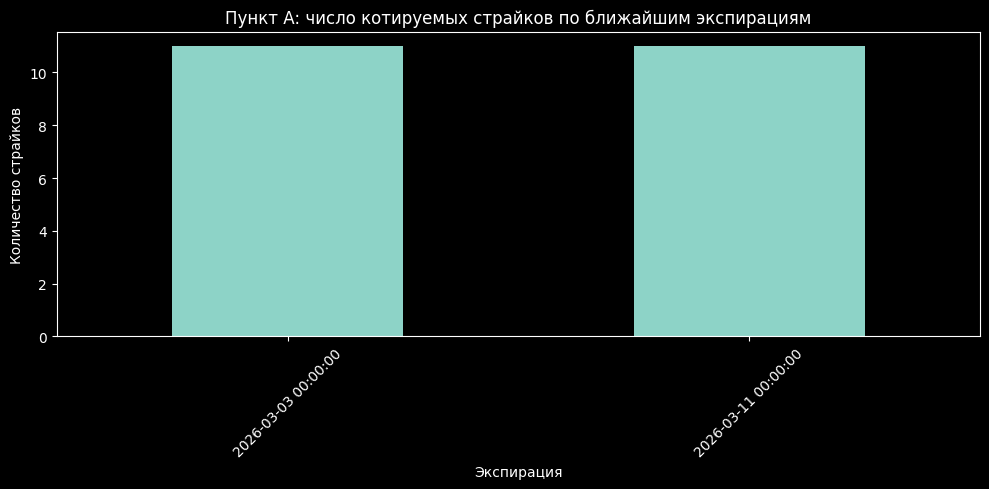

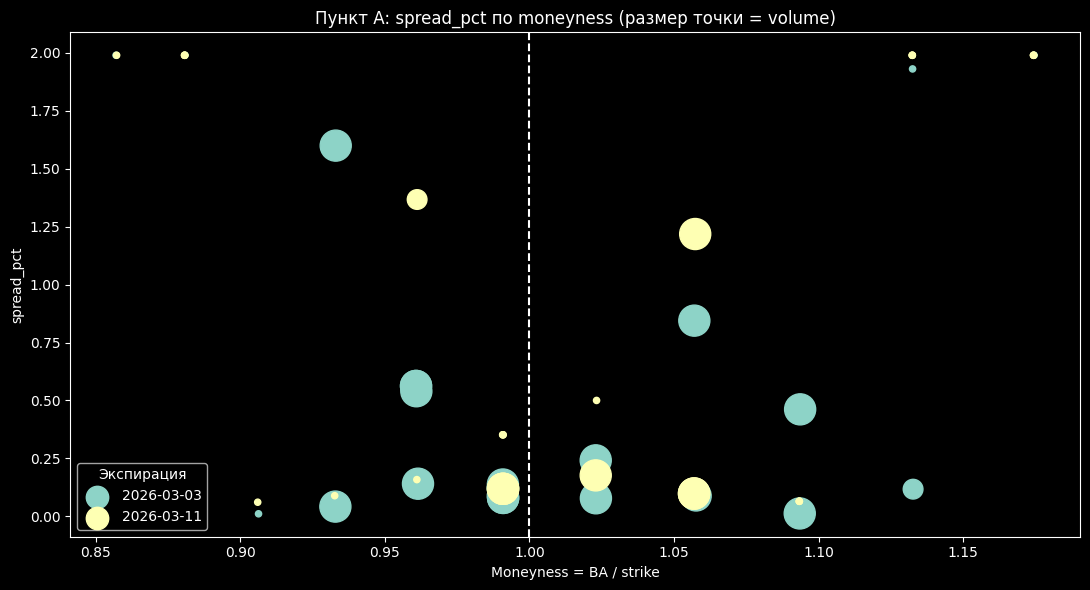

In [83]:

def task_A_liquidity_map(options, latest_spot):
    selected_expiries = nearest_expiries(options, n=N_NEAREST_EXPIRIES)
    a_df = options[options['expiration_date'].isin(selected_expiries)].copy()

    summary_rows = []
    for expiry, x in a_df.groupby('expiration_date'):
        quoted = x[x['is_quoted']].copy()

        row = {
            'expiration_date': expiry,
            'contracts_total': len(x),
            'quoted_contracts': int(x['is_quoted'].sum()),
            'quoted_share_pct': round(100 * x['is_quoted'].mean(), 2),
            'quoted_strikes': quoted['strike'].nunique(),
            'avg_volume_quoted': round(quoted['volume'].mean(), 2) if len(quoted) > 0 else np.nan,
            'median_volume_quoted': round(quoted['volume'].median(), 2) if len(quoted) > 0 else np.nan,
            'median_spread_pct_quoted': round(quoted['spread_pct'].median(), 4) if len(quoted) > 0 else np.nan,
            'mean_spread_pct_quoted': round(quoted['spread_pct'].mean(), 4) if len(quoted) > 0 else np.nan,
            'atm_quoted_contracts': int(((x['is_quoted']) & (x['abs_mny_distance'] <= 0.05)).sum()),
            'otm_quoted_contracts': int(((x['is_quoted']) & (x['abs_mny_distance'] > 0.05)).sum()),
            'spot_reference': round(x['BA'].median(), 2)
        }
        summary_rows.append(row)

    summary = pd.DataFrame(summary_rows).sort_values('expiration_date')
    summary.to_csv(OUTPUT_DIR / 'A_liquidity_summary.csv', index=False)

    print('Таблица для пункта A:')
    print(summary)
    strikes_by_exp = (
        a_df[a_df['is_quoted']]
        .groupby('expiration_date')['strike']
        .nunique()
        .sort_index()
    )

    plt.figure(figsize=(10, 5))
    strikes_by_exp.plot(kind='bar')
    plt.title('Пункт A: число котируемых страйков по ближайшим экспирациям')
    plt.xlabel('Экспирация')
    plt.ylabel('Количество страйков')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    plt.figure(figsize=(11, 6))
    for expiry in selected_expiries:
        temp = a_df[(a_df['expiration_date'] == expiry) & (a_df['is_quoted'])].copy()
        temp = temp.sort_values('moneyness')

        if len(temp) > 0:
            plt.scatter(
                temp['moneyness'],
                temp['spread_pct'],
                s=np.clip(temp['volume'], 20, 500),
                label=str(expiry.date())
            )
    plt.axvline(1.0, linestyle='--')
    plt.title('Пункт A: spread_pct по moneyness (размер точки = volume)')
    plt.xlabel('Moneyness = BA / strike')
    plt.ylabel('spread_pct')
    plt.legend(title='Экспирация')
    plt.tight_layout()
    plt.show()
task_A_liquidity_map(options, latest_spot)


# IV и Улыбка
- Выыод:

Наиболее стабильной улыбка волатильности выглядит для экспирации 2026-03-11, поскольку у нее ниже разброс IV (std IV = 0.1126) и лучше качество котировок. Более шумная улыбка наблюдается для экспирации 2026-03-03, где разброс IV выше (std IV = 0.1864). Как правило, наиболее адекватные значения IV наблюдаются около ATM, а на дальних страйках возможны искажения из-за слабой ликвидности.

Сводка по IV:
  expiration_date  contracts_total  contracts_with_iv  iv_coverage_pct  \
0      2026-02-24               28                  0             0.00   
1      2026-03-03               30                 25            83.33   
2      2026-03-11               38                 26            68.42   
3      2026-03-18               47                 39            82.98   
4      2026-04-14               32                 23            71.88   
5      2026-06-16               15                  9            60.00   
6      2026-06-17               18                 12            66.67   
7      2026-09-15               34                  9            26.47   
8      2027-12-15               69                  1             1.45   
9      2028-03-14              170                  0             0.00   

   median_iv  std_iv  median_spread_pct  median_volume  
0        NaN     NaN                NaN          505.0  
1     0.2768  0.1864             0.5006          907.5  


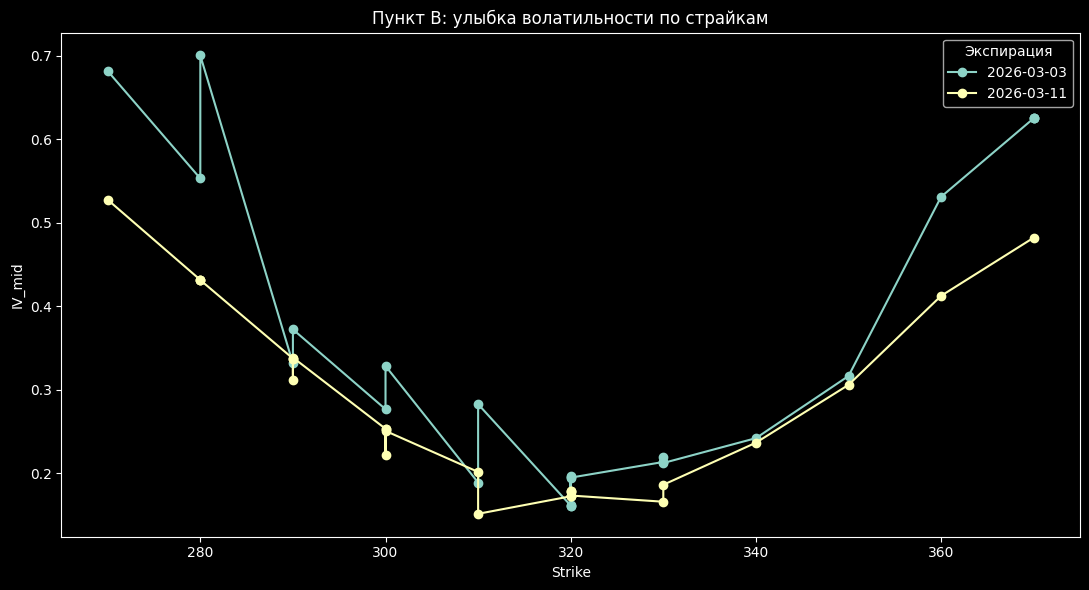

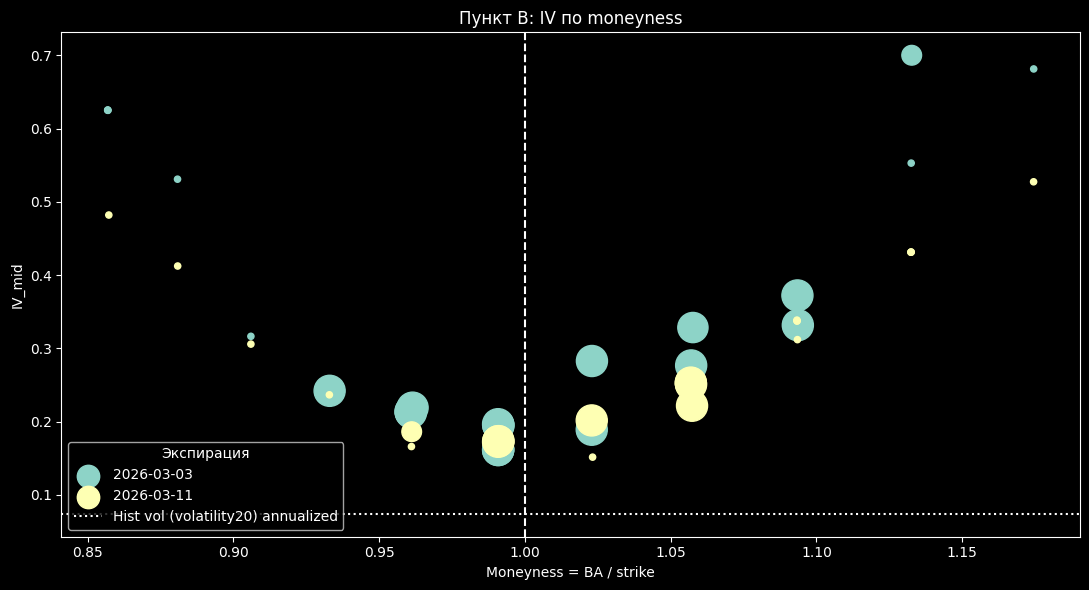

In [84]:
def task_B_iv_smile(options, latest_hist_vol):
    b_df = options.copy()

    valid_mask = (
        (b_df['mid'] > 0) &
        (b_df['T'] > 0) &
        (b_df['strike'] > 0) &
        (b_df['BA'] > 0)
    )

    b_df['IV_mid'] = np.nan

    b_df.loc[valid_mask, 'IV_mid'] = b_df.loc[valid_mask].apply(
        lambda row: implied_volatility_mid(
            mid_price=row['mid'],
            spot=row['BA'],
            strike=row['strike'],
            time_to_expiry=row['T'],
            rate=RISK_FREE_RATE,
            option_type=row['type']
        ),
        axis=1
    )

    b_df.to_csv(OUTPUT_DIR / 'B_options_with_iv.csv', index=False)

    summary_rows = []
    for expiry, x in b_df.groupby('expiration_date'):
        row = {
            'expiration_date': expiry,
            'contracts_total': len(x),
            'contracts_with_iv': int(x['IV_mid'].notna().sum()),
            'iv_coverage_pct': round(100 * x['IV_mid'].notna().mean(), 2),
            'median_iv': round(x['IV_mid'].median(), 4) if x['IV_mid'].notna().any() else np.nan,
            'std_iv': round(x['IV_mid'].std(), 4) if x['IV_mid'].notna().any() else np.nan,
            'median_spread_pct': round(x['spread_pct'].median(), 4) if x['spread_pct'].notna().any() else np.nan,
            'median_volume': round(x['volume'].median(), 2) if x['volume'].notna().any() else np.nan
        }
        summary_rows.append(row)

    iv_summary = pd.DataFrame(summary_rows).sort_values('expiration_date')
    print('Сводка по IV:')
    print(iv_summary.head(10))
    selected_expiries = nearest_expiries(b_df, n=N_NEAREST_EXPIRIES)
    smile_df = b_df[
        (b_df['expiration_date'].isin(selected_expiries)) &
        (b_df['IV_mid'].notna())
    ].copy()

    plt.figure(figsize=(11, 6))
    for expiry in selected_expiries:
        temp = smile_df[smile_df['expiration_date'] == expiry].sort_values('strike')

        if len(temp) > 0:
            plt.plot(
                temp['strike'],
                temp['IV_mid'],
                marker='o',
                label=str(expiry.date())
            )

    plt.title('Пункт B: улыбка волатильности по страйкам')
    plt.xlabel('Strike')
    plt.ylabel('IV_mid')
    plt.legend(title='Экспирация')
    plt.tight_layout()
    plt.show()
    plt.figure(figsize=(11, 6))
    for expiry in selected_expiries:
        temp = smile_df[smile_df['expiration_date'] == expiry].sort_values('moneyness')

        if len(temp) > 0:
            plt.scatter(
                temp['moneyness'],
                temp['IV_mid'],
                s=np.clip(temp['volume'], 20, 500),
                label=str(expiry.date())
            )

    plt.axvline(1.0, linestyle='--')
    plt.axhline(latest_hist_vol, linestyle=':', label=f'Hist vol ({USE_VOL_COLUMN}) annualized')
    plt.title('Пункт B: IV по moneyness')
    plt.xlabel('Moneyness = BA / strike')
    plt.ylabel('IV_mid')
    plt.legend(title='Экспирация')
    plt.tight_layout()
    plt.show()
task_B_iv_smile(options, latest_hist_vol)



# Delta hedge

In [85]:
Options_SBER.head()

,Unnamed: 0,parsing_datetime,code,type,strike,T,bid,ask,BA,volume,mid,spread_pct,moneyness
0,0,2026-02-25 23:01:23.365000,SR125CI9,CALL,125.0,3.562,135.0,0.0,317.1,0,67.5,-2.0,2.536800
1,1,2026-02-25 23:01:23.705650,SR185CU9,PUT,185.0,3.562,0.0,0.0,317.1,0,0.0,NaN,1.714054
2,2,2026-02-25 23:01:23.981718,SR350CI8,CALL,350.0,2.565,0.0,0.0,317.1,0,0.0,NaN,0.906000
3,3,2026-02-25 23:01:24.253901,SR270CR6,PUT,270.0,0.304,0.0,3.0,317.1,0,1.5,2.0,1.174444
4,4,2026-02-25 23:01:24.519739,SR315CX9,PUT,315.0,3.811,0.0,0.0,317.1,0,0.0,NaN,1.006667


In [86]:
Sber.tail()

,Unnamed: 0,time,close,r,volatility20,volatility60
1572,1572,2026-02-21 00:00:00+00:00,313.79,-0.000669,0.005010,0.005487
1573,1573,2026-02-22 00:00:00+00:00,313.54,-0.000797,0.005027,0.005485
1574,1574,2026-02-23 00:00:00+00:00,314.16,0.001975,0.005025,0.005483
1575,1575,2026-02-24 00:00:00+00:00,316.15,0.006314,0.004721,0.005531
1576,1576,2026-02-25 00:00:00+00:00,317.30,0.003631,0.004677,0.005508


In [87]:
opt = Options_SBER[
    (Options_SBER['moneyness'] > 0.95) &
    (Options_SBER['moneyness'] < 1.25)
]

In [88]:
opt

,Unnamed: 0,parsing_datetime,code,type,strike,T,bid,ask,BA,volume,mid,spread_pct,moneyness
3,3,2026-02-25 23:01:24.253901,SR270CR6,PUT,270.0,0.304,0.00,3.00,317.10,0,1.500,2.000000,1.174444
4,4,2026-02-25 23:01:24.519739,SR315CX9,PUT,315.0,3.811,0.00,0.00,317.10,0,0.000,NaN,1.006667
6,6,2026-02-25 23:01:25.050479,SR260CB6D,CALL,260.0,-0.003,0.00,0.00,317.10,0,0.000,NaN,1.219615
13,13,2026-02-25 23:01:26.888993,SR290CX8,PUT,290.0,2.815,0.00,0.00,317.10,0,0.000,NaN,1.093448
16,16,2026-02-25 23:01:27.658754,SR270CX8,PUT,270.0,2.815,0.00,0.00,317.10,0,0.000,NaN,1.174444
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1985,1985,2026-02-25 23:16:21.500818,SR330CC6,CALL,330.0,0.055,1.45,2.06,317.23,5556,1.755,0.347578,0.961303
1988,1988,2026-02-25 23:16:22.943231,SR265CX8,PUT,265.0,2.815,0.00,0.00,317.14,0,0.000,NaN,1.196755
1992,1992,2026-02-25 23:16:24.853115,SR305CX8,PUT,305.0,2.815,0.00,0.00,317.14,0,0.000,NaN,1.039803
1997,1997,2026-02-25 23:16:27.206400,SR330CO6A,PUT,330.0,0.016,11.51,13.25,317.29,4009,12.380,0.140549,0.961485


In [89]:
option = opt.loc[1985,:]
option

Unnamed: 0                                1985
parsing_datetime    2026-02-25 23:16:21.500818
code                                  SR330CC6
type                                      CALL
strike                                   330.0
T                                        0.055
bid                                       1.45
ask                                       2.06
BA                                      317.23
volume                                    5556
mid                                      1.755
spread_pct                            0.347578
moneyness                             0.961303
Name: 1985, dtype: object

In [90]:
volatility = Sber['r'].std()
share = Sber[Sber['time'] == '2026-02-25 00:00:00+00:00']
share

,Unnamed: 0,time,close,r,volatility20,volatility60
1576,1576,2026-02-25 00:00:00+00:00,317.3,0.003631,0.004677,0.005508


In [91]:
option

Unnamed: 0                                1985
parsing_datetime    2026-02-25 23:16:21.500818
code                                  SR330CC6
type                                      CALL
strike                                   330.0
T                                        0.055
bid                                       1.45
ask                                       2.06
BA                                      317.23
volume                                    5556
mid                                      1.755
spread_pct                            0.347578
moneyness                             0.961303
Name: 1985, dtype: object

In [92]:
BS = Black_Sholse(K=option['strike'],
                  option_type=option['type'],
                  T=option['T'],
                  volatility=volatility *  np.sqrt(252),
                  S_0=share['close'],
)
BS.Black_Sholse()
delta = BS.delta[0]
print(f'Delta = {delta}')

Delta = 0.3733301273471434


# Стоимость стратегии

In [93]:
cost_of_delta_hedge =  delta*share['close'] - option['mid']
print('Стоимость стратегии при покупки и продажи опциона по mid:',cost_of_delta_hedge)
cost_of_delta_hedge = delta*share['close'] - option['ask']
print('Стоимость стратегии при покупки опциона по ask, продажи по bid:',cost_of_delta_hedge)


Стоимость стратегии при покупки и продажи опциона по mid: 1576    116.702649
Name: close, dtype: float64
Стоимость стратегии при покупки опциона по ask, продажи по bid: 1576    116.397649
Name: close, dtype: float64


# Protective put
- Покупае БА, а так же покупаем Put опцион, чтобы снизить гипотетические потери

In [94]:
protective_put = opt[(opt['type'] == 'PUT') &
    (opt['bid'] > 0) &
    (opt['ask'] > 0)]
protective_put.head()

,Unnamed: 0,parsing_datetime,code,type,strike,T,bid,ask,BA,volume,mid,spread_pct,moneyness
46,46,2026-02-25 23:01:35.629779,SR290CO6,PUT,290.0,0.055,0.17,0.42,317.1,2180,0.295,0.847458,1.093448
47,47,2026-02-25 23:01:35.887612,SR310CO6,PUT,310.0,0.055,1.54,1.80,317.1,3991,1.670,0.155689,1.022903
63,63,2026-02-25 23:01:40.063390,SR300CO6,PUT,300.0,0.055,0.39,0.55,317.1,7165,0.470,0.340426,1.057000
86,86,2026-02-25 23:01:46.017784,SR320CO6B,PUT,320.0,0.036,4.60,5.18,317.1,962,4.890,0.118609,0.990938
114,114,2026-02-25 23:01:53.347757,SR330CO6,PUT,330.0,0.055,11.13,12.73,317.1,500,11.930,0.134116,0.960909


In [95]:
"""
Покупаем БА по 317.1 рублей
одновременно с этим покупаем Put опцион
со страйком 310
"""
option = protective_put.loc[47,:]
option

Unnamed: 0                                  47
parsing_datetime    2026-02-25 23:01:35.887612
code                                  SR310CO6
type                                       PUT
strike                                   310.0
T                                        0.055
bid                                       1.54
ask                                        1.8
BA                                       317.1
volume                                    3991
mid                                       1.67
spread_pct                            0.155689
moneyness                             1.022903
Name: 47, dtype: object

Text(0.5, 1.0, 'Выплата по стратегии')

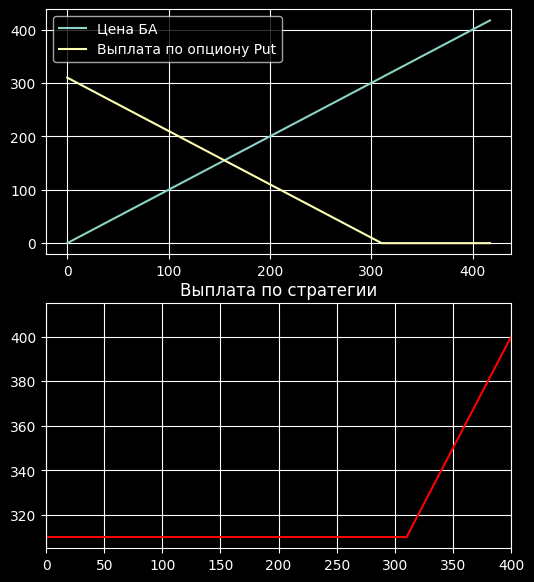

In [96]:
S = np.linspace(0,
                option['BA'] + 100,
                1000)
put_payoff = np.maximum(option['strike'] - S, 0)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6,7))
ax1.plot(S, S,label='Цена БА')
ax1.plot(S, put_payoff,label='Выплата по опциону Put')
ax1.legend()
ax1.grid(True)
S_intersection = option['strike'] / 2
ax2.plot(np.array([0,put_payoff[0]]),
         np.array([put_payoff[0],put_payoff[0]]),color='red')
y = np.linspace(put_payoff[0],
                put_payoff[0] + 100,
                1000)
x = np.linspace(put_payoff[0],
                put_payoff[0] + 100,
                1000)
ax2.plot(x,y,color='red')
ax2.grid(True)
ax2.set_xlim(0, 400)
ax2.set_title('Выплата по стратегии')






# Стоимость стратегии

In [97]:
option

Unnamed: 0                                  47
parsing_datetime    2026-02-25 23:01:35.887612
code                                  SR310CO6
type                                       PUT
strike                                   310.0
T                                        0.055
bid                                       1.54
ask                                        1.8
BA                                       317.1
volume                                    3991
mid                                       1.67
spread_pct                            0.155689
moneyness                             1.022903
Name: 47, dtype: object

Стоимость стратегии при покупки и продажи опциона по mid: 318.77000000000004


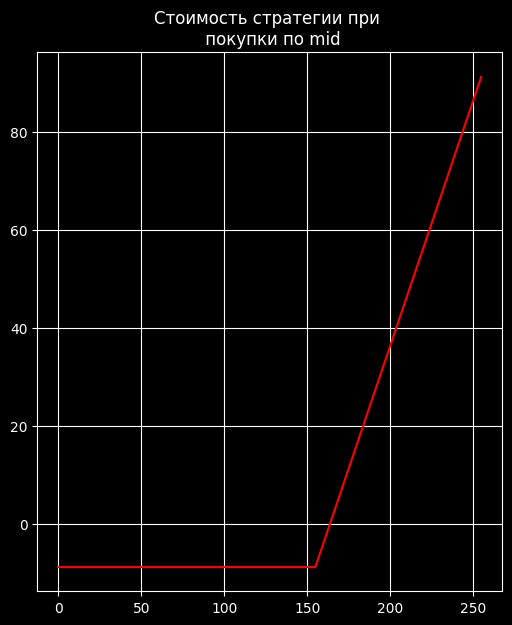

In [98]:
cost_of_protective_put = option['mid'] + option["BA"]
S = np.linspace(0,
                option['BA'] + 100,
                1000)
put_payoff = np.maximum(option['strike'] - S, 0)
fig, ax2 = plt.subplots(1, 1, figsize=(6,7))
S_intersection = option['strike'] / 2
ax2.plot(np.array([0,S_intersection ]),
         np.array([put_payoff[0] - cost_of_protective_put,put_payoff[0] - cost_of_protective_put]),color='red')
y = np.linspace(put_payoff[0] - cost_of_protective_put,
                put_payoff[0] + 100 - cost_of_protective_put,
                1000)
x = np.linspace(S_intersection,
                S_intersection + 100,
                1000)
ax2.plot(x,y,color='red')
ax2.grid(True)
ax2.set_title('Стоимость стратегии при \n покупки по mid')
print('Стоимость стратегии при покупки и продажи опциона по mid:',cost_of_protective_put)


Стоимость стратегии при покупки опциона по ask, продажи по bid: 318.90000000000003


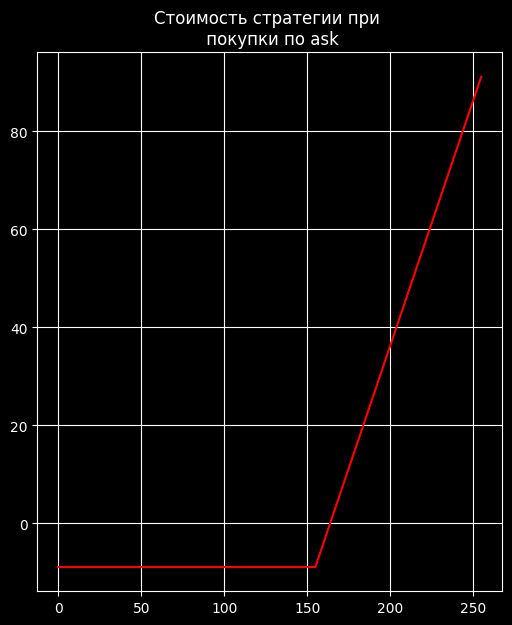

In [99]:
cost_of_protective_put = option['ask'] + option["BA"]
S = np.linspace(0,
                option['BA'] + 100,
                1000)
put_payoff = np.maximum(option['strike'] - S, 0)
fig, ax2 = plt.subplots(1, 1, figsize=(6,7))
S_intersection = option['strike'] / 2
ax2.plot(np.array([0,S_intersection ]),
         np.array([put_payoff[0] - cost_of_protective_put,put_payoff[0] - cost_of_protective_put]),color='red')
y = np.linspace(put_payoff[0] - cost_of_protective_put,
                put_payoff[0] + 100 - cost_of_protective_put,
                1000)
x = np.linspace(S_intersection,
                S_intersection + 100,
                1000)
ax2.plot(x,y,color='red')
ax2.grid(True)
ax2.set_title('Стоимость стратегии при \n покупки по ask')
print('Стоимость стратегии при покупки опциона по ask, продажи по bid:',cost_of_protective_put)



# Оценка параметров GBM

Процесс Geometric Brownian Motion описывается:

$$ dS_t = \mu S_t \, dt + \sigma S_t \, dW_t $$

Берём логарифм и дискретизируем:

$$ X_t = \ln S_t, \quad$$
$$X_{t+\Delta t} - X_t \sim \mathcal{N}\Big((\mu - \frac{\sigma^2}{2}) \Delta t, \, \sigma^2 \Delta t \Big) $$


Функция правдоподобия для наблюдений $X_0, \dots, X_n$:

$$ L(\mu, \sigma \mid X_0, \dots, X_n) = \prod_{i=1}^{n} \frac{1}{\sqrt{2\pi \sigma^2 \Delta t}}
 \exp\Bigg\{ - \frac{(X_i - X_{i-1} - (\mu - \frac{\sigma^2}{2}) \Delta t)^2}{2 \sigma^2 \Delta t} \Bigg\} $$


Логарифм функции правдоподобия:

$$ \ell(\mu, \sigma) = -\frac{n}{2} \ln(2\pi) - n \ln \sigma - \frac{1}{2\sigma^2 \Delta t} \sum_{i=1}^{n} \Big(X_i - X_{i-1} - (\mu - \frac{\sigma^2}{2}) \Delta t \Big)^2 $$


Максимизация $\ell(\mu, \sigma)$ по $\mu$ и $\sigma$ даёт оценки:

$$ \hat{\sigma}^2 = \frac{1}{n \Delta t} \sum_{i=1}^{n} \Big(X_i - X_{i-1} - \overline{\Delta X}\Big)^2, \quad
\overline{\Delta X} = \frac{1}{n} \sum_{i=1}^{n} (X_i - X_{i-1}) $$


$$ \hat{\mu} = \frac{1}{n \Delta t} \sum_{i=1}^{n} (X_i - X_{i-1}) + \frac{1}{2} \hat{\sigma}^2 $$


# Дискретная формула для генерации траектории цены акции:


$$ S_{t+\Delta t} = S_t \cdot \exp\Bigg( \big(\mu - \frac{\sigma^2}{2}\big)\Delta t + \sigma \sqrt{\Delta t} \, \epsilon_t \Bigg),
\quad \epsilon_t \sim \mathcal{N}(0,1) $$

где:
- $S_t$ --- цена акции в момент $t$,
- $\mu$ --- дрейф (средняя доходность),
- $\sigma$ --- волатильность,
- $\Delta t$ --- временной шаг между соседними наблюдениями (в годовых единицах),
- $\epsilon_t$ --- стандартная нормальная случайная величина.

In [100]:
Sber.tail()

,Unnamed: 0,time,close,r,volatility20,volatility60
1572,1572,2026-02-21 00:00:00+00:00,313.79,-0.000669,0.005010,0.005487
1573,1573,2026-02-22 00:00:00+00:00,313.54,-0.000797,0.005027,0.005485
1574,1574,2026-02-23 00:00:00+00:00,314.16,0.001975,0.005025,0.005483
1575,1575,2026-02-24 00:00:00+00:00,316.15,0.006314,0.004721,0.005531
1576,1576,2026-02-25 00:00:00+00:00,317.30,0.003631,0.004677,0.005508


In [101]:
def St_dt(St,dt = 1):
    r = Sber['r'].dropna()
    r_av = np.mean(r)
    sigma2 = np.sum((r - r_av)**2) / (len(r) * dt )
    mu = np.sum(r) / (len(r) * dt) + 0.5 * sigma2
    Stdt = St * np.exp((mu-0.5*sigma2)*dt + np.sqrt(sigma2 * dt) * np.random.normal(loc=0,scale=1))
    return Stdt

Text(0.5, 1.0, 'Симуляция движения акции \n на 14 дней')

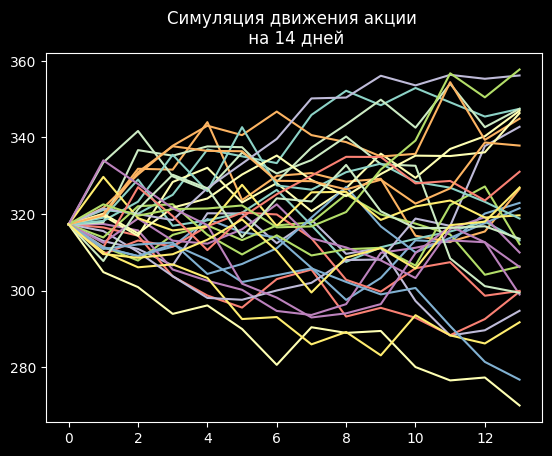

In [102]:

np.random.seed(42)
fig,ax = plt.subplots(1,1)
option = opt.loc[1985,:]
T = int(option['T'] * 252) + 1
rep = 30
for _i in range(rep):
    S = 317.30
    Prices = []
    for _ in range(T):
        Prices.append(S)
        S = St_dt(St = S)
    ax.plot(Prices)
ax.set_title(f'Симуляция движения акции \n на {T} дней')


# Стртатегия Delta hedge

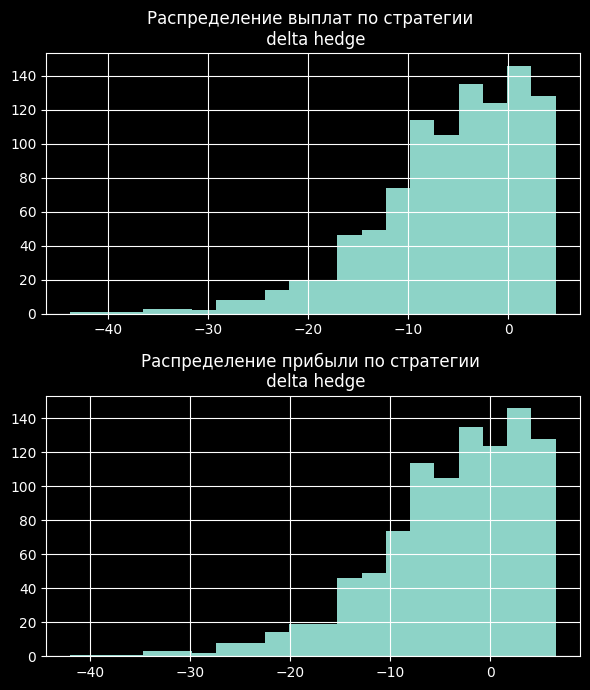

In [103]:

option = opt.loc[1985,:]
def delta_hedge(rep,T,strike,S0=317.30):
    S_start = S0
    pay_off = []
    profit = []
    for _i in range(rep):
        S = S0
        for _ in range(T):
            S = St_dt(St = S)
        pay_off.append(- np.maximum(S - strike, 0) + (S-S_start)*delta)
        profit.append(- np.maximum(S - strike, 0) + (S-S_start)*delta + option['mid'])
    fig,(ax1,ax2) = plt.subplots(2,1,figsize=(6,7))
    ax1.hist(pay_off,bins=20)
    ax1.set_title("Распределение выплат по стратегии \n delta hedge")
    ax1.grid(True)
    ax2.hist(profit,bins=20)
    ax2.set_title("Распределение прибыли по стратегии \n delta hedge")
    ax2.grid(True)
    plt.tight_layout()
    return pay_off,profit

pay_off,profit = delta_hedge(rep = 1000,T= int(option['T'] * 252) + 1,strike=option['strike'],S0=option["BA"])

In [104]:
option

Unnamed: 0                                1985
parsing_datetime    2026-02-25 23:16:21.500818
code                                  SR330CC6
type                                      CALL
strike                                   330.0
T                                        0.055
bid                                       1.45
ask                                       2.06
BA                                      317.23
volume                                    5556
mid                                      1.755
spread_pct                            0.347578
moneyness                             0.961303
Name: 1985, dtype: object

# Метрики

In [105]:
print(f'Средний pay off = {np.mean(pay_off)}')
print(f'5% худшие pay off  = {np.percentile(pay_off, 5)}')
print(f'Минимальный pay off  = {np.min(pay_off)}')
print(f'Средний profit = {np.mean(profit)}')
print(f'5% худшие profit  = {np.percentile(profit, 5)}')
print(f'Минимальный profit  = {np.min(profit)}')

Средний pay off = -5.725638919728497
5% худшие pay off  = -20.11243531052312
Минимальный pay off  = -43.72287923747034
Средний profit = -3.970638919728497
5% худшие profit  = -18.357435310523122
Минимальный profit  = -41.967879237470335


# Стратегия Protective Put

In [106]:
option = protective_put.loc[47,:]
S = np.linspace(0,
                option['BA'] + 100,
                1000)
put_payoff = np.maximum(option['strike'] - S, 0)
put_payoff[0]


np.float64(310.0)

In [107]:
option

Unnamed: 0                                  47
parsing_datetime    2026-02-25 23:01:35.887612
code                                  SR310CO6
type                                       PUT
strike                                   310.0
T                                        0.055
bid                                       1.54
ask                                        1.8
BA                                       317.1
volume                                    3991
mid                                       1.67
spread_pct                            0.155689
moneyness                             1.022903
Name: 47, dtype: object

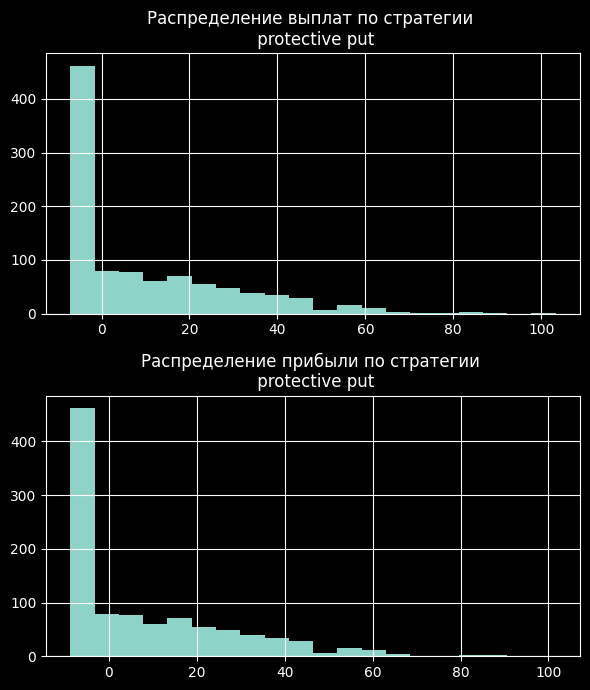

In [108]:
def prot_put(rep,T,strike,S0=317.1):
    pay_off = []
    profit = []
    S_start = S0
    for _i in range(rep):
        S = S0
        for _ in range(T):
            S = St_dt(St = S)
        pay_off.append(np.maximum(strike - S, 0) + (S - S_start))
        profit.append(np.maximum(strike - S, 0) + (S - S_start) - option['mid'])
    fig,(ax1,ax2) = plt.subplots(2,1,figsize=(6,7))
    ax1.hist(pay_off,bins=20)
    ax1.set_title("Распределение выплат по стратегии \n protective put")
    ax1.grid(True)
    ax2.hist(profit,bins=20)
    ax2.set_title("Распределение прибыли по стратегии \n protective put")
    ax2.grid(True)
    plt.tight_layout()
    return pay_off,profit
pay_off,profit = prot_put(rep = 1000,T= int(option['T'] * 252) + 1,S0=option["BA"],strike=option["strike"])

# Метрика

In [109]:
print(f'Средний pay off = {np.mean(pay_off)}')
print(f'5% худшие pay off  = {np.percentile(pay_off, 5)}')
print(f'Минимальный pay off  = {np.min(pay_off)}')
print(f'Средний profit = {np.mean(profit)}')
print(f'5% худшие profit  = {np.percentile(profit, 5)}')
print(f'Минимальный profit  = {np.min(profit)}')

Средний pay off = 9.02102112263502
5% худшие pay off  = -7.100000000000023
Минимальный pay off  = -7.100000000000023
Средний profit = 7.35102112263502
5% худшие profit  = -8.770000000000023
Минимальный profit  = -8.770000000000023
